# Coral Reef Data EDA
Exploratory Data Analysis for the CoralMorph Search Application.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv('Coral_reef_data.csv', encoding='cp1252')
# Display first few rows
df.head()

,Species Name,Authority / Year,Characters:,Description,Colour:,Color,Habitat:,Habitat,Abundance:,Abundance
0,Acanthastrea bowerbanki,"Haime and Milne Edwards, 1857",Characters:,Colonies are encrusting and usually small. Cor...,Colour:,"Usually pale grey, brown or rust coloured, oft...",Habitat:,Lower reef slopes protected from wave action.,Abundance:,Rare except in subtropical localities of easte...
1,Acanthastrea brevis,"Milne Edwards and Haime, 1849",Characters:,Colonies are mostly submassive. Corallites are...,Colour:,"Uniform or mottled brown, yellow or green.",Habitat:,Shallow reef environments.,Abundance:,Uncommon.
2,Acanthastrea echinata,"(Dana, 1846)",Characters:,Colonies are encrusting to massive and are rar...,Colour:,"Uniform or mottled dull brown, grey or green, ...",Habitat:,Most reef environments.,Abundance:,"Usually uncommon, but by far the most common ..."
3,Acanthastrea faviaformis,"Veron, 2000",Characters:,"Colonies are encrusting to massive, usually le...",Colour:,Mottled browns.,Habitat:,Shallow reef environments.,Abundance:,Uncommon.
4,Acanthastrea hemprichii,"(Ehrenberg, 1834)",Characters:,Colonies are encrusting to massive and frequen...,Colour:,"Mottled browns and greens, commonly with brown...",Habitat:,Most reef environments.,Abundance:,Uncommon.


## 1. Data Inspection and Cleaning
Analyze the raw column structure and map them to meaningful variables.

In [19]:
df.value_counts(df.columns[4])

Colour:
Colour:    831
Name: count, dtype: int64

In [21]:
# Display column names
print("Original Columns:", df.columns.tolist())

# Map columns by index to handle duplicates and labels
column_mapping = {
    df.columns[0]: "species_name",
    df.columns[1]: "authority",
    df.columns[3]: "description",
    df.columns[5]: "color",
    df.columns[7]: "habitat",
    df.columns[9]: "abundance"
}
df_clean = df.rename(columns=column_mapping)
df_clean = df_clean[["species_name", "description", "color", "habitat", "abundance"]]

# Inspect Datatypes
df_clean.info()

Original Columns: ['Species Name ', 'Authority / Year', 'Characters:', 'Description', 'Colour:', 'Color', 'Habitat:', 'Habitat', 'Abundance:', 'Abundance']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831 entries, 0 to 830
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   species_name  831 non-null    object
 1   description   831 non-null    object
 2   color         831 non-null    object
 3   habitat       831 non-null    object
 4   abundance     829 non-null    object
dtypes: object(5)
memory usage: 32.6+ KB


## 2. Summary Statistics
Basic counts and null checks.

In [22]:
# Check for nulls
print("Null values per column:\n", df_clean.isnull().sum())

# Basic summary for categorical data
print(df_clean.describe(include='all'))

Null values per column:
 species_name    0
description     0
color           0
habitat         0
abundance       2
dtype: int64
              species_name                                        description  \
count                  831                                                831   
unique                 831                                                830   
top     Zoopilus echinatus  Colonies are massive with a tendency to form c...   
freq                     1                                                  2   

              color                     habitat  abundance  
count           831                         831        829  
unique          724                         413        189  
top     Pale brown.  Shallow reef environments.  Uncommon.  
freq             27                         147        204  


## 3. Abundance Distribution
Visualizing how common or rare these species are.

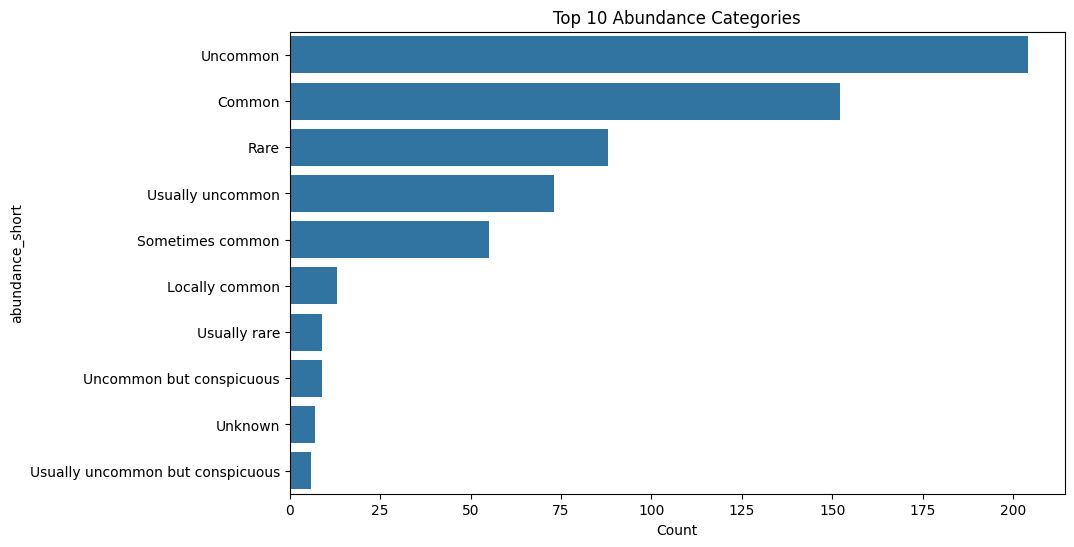

In [23]:
plt.figure(figsize=(10, 6))
# Clean abundance text for visualization (taking first few words)
df_clean['abundance_short'] = df_clean['abundance'].astype(str).str.split('.').str[0].str.strip()
sns.countplot(y='abundance_short', data=df_clean, order=df_clean['abundance_short'].value_counts().index[:10])
plt.title('Top 10 Abundance Categories')
plt.xlabel('Count')
plt.show()

## 4. Description Length Analysis
Analyze the length of descriptions to ensure they provide enough signal for embeddings.

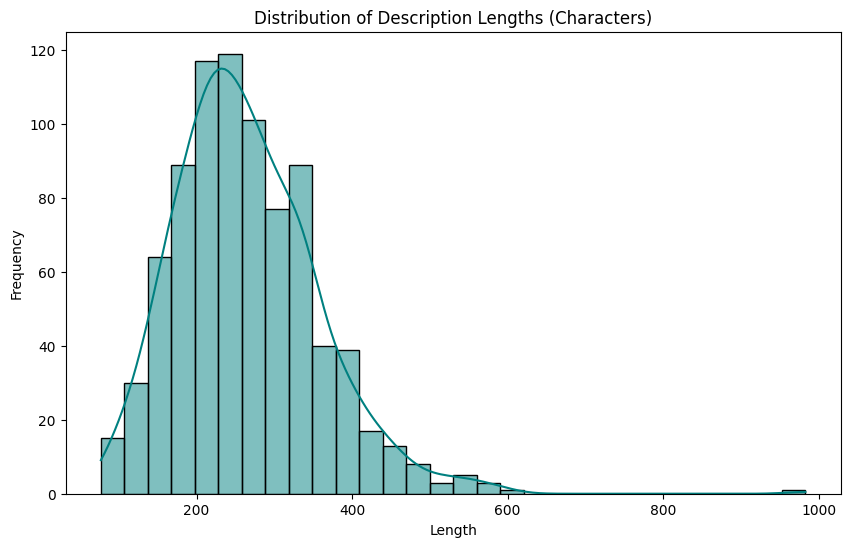

In [24]:
df_clean['desc_len'] = df_clean['description'].astype(str).apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['desc_len'], bins=30, kde=True, color='teal')
plt.title('Distribution of Description Lengths (Characters)')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

## 5. Most Common Colors
Identifying the primary colors mentioned in the dataset.

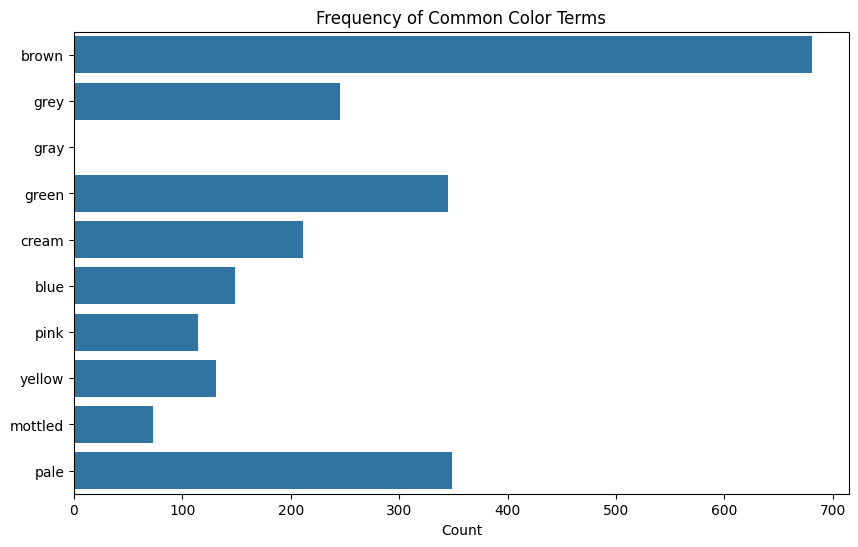

In [25]:
from collections import Counter
import re

# Simple word extraction for colors
colors_text = " ".join(df_clean['color'].astype(str).tolist()).lower()
# Basic regex to find common color words
common_colors = ['brown', 'grey', 'gray', 'green', 'cream', 'blue', 'pink', 'yellow', 'mottled', 'pale']
color_counts = {color: colors_text.count(color) for color in common_colors}

plt.figure(figsize=(10, 6))
sns.barplot(x=list(color_counts.values()), y=list(color_counts.keys()))
plt.title('Frequency of Common Color Terms')
plt.xlabel('Count')
plt.show()

## 6. Additional EDA & Feature Engineering
We'll compute text- and color-based features, create an ordinal abundance field, and produce quick summaries and plots. This cell does not overwrite your original CSV unless you explicitly save results.

In [ ]:
# Robust CSV read (fallback encodings)
import pandas as pd
import numpy as np
from collections import Counter

def read_csv_flexible(path):
    encodings = [None, 'cp1252', 'latin-1', 'utf-8-sig']
    last_exc = None
    for enc in encodings:
        try:
            if enc is None:
                return pd.read_csv(path)
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_exc = e
    raise last_exc

# load using fallback encodings
df_all = read_csv_flexible('Coral_reef_data.csv')
print('Loaded:', df_all.shape)
# Try to infer useful column names (non-destructive)
cols = df_all.columns.tolist()
print('Columns:', cols)
mapping = {}
if len(cols) > 0:
    mapping[cols[0]] = 'species_name'
if len(cols) > 3:
    mapping[cols[3]] = 'description'
if len(cols) > 5:
    mapping[cols[5]] = 'color'
if len(cols) > 7:
    mapping[cols[7]] = 'habitat'
if len(cols) > 9:
    mapping[cols[9]] = 'abundance'
# prefer explicit matches if present
for c in cols:
    if 'species' in c.lower() and 'species_name' not in mapping.values():
        mapping[c] = 'species_name'
    if 'description' in c.lower() or 'desc' in c.lower():
        mapping[c] = 'description'
    if 'color' in c.lower() or 'colour' in c.lower():
        mapping[c] = 'color'
    if 'habitat' in c.lower():
        mapping[c] = 'habitat'
    if 'abund' in c.lower():
        mapping[c] = 'abundance'

df = df_all.rename(columns=mapping)
keep = [c for c in ['species_name','description','color','habitat','abundance'] if c in df.columns]
df = df[keep + [c for c in df.columns if c not in keep]]
df.info()

In [ ]:
# Feature engineering: text features, color tokens, abundance ordinal
# Text features
if 'description' in df.columns:
    s = df['description'].astype(str).fillna('')
    df['desc_char_len'] = s.apply(len)
    df['desc_word_count'] = s.str.split().apply(len)
    df['desc_avg_word_len'] = s.apply(lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
    display(df[['desc_char_len','desc_word_count','desc_avg_word_len']].describe().round(2))
else:
    print('No description column found; skipping text features')

# Color features
if 'color' in df.columns:
    all_color_text = ' '.join(df['color'].astype(str).fillna('').tolist()).lower()
    toks = [t.strip('.,()') for t in all_color_text.split() if t]
    counts = Counter(toks)
    top = [c for c,_ in counts.most_common(8)]
    def pick_primary(txt):
        t = str(txt).lower()
        for c in top:
            if c in t:
                return c
        return 'other'
    df['color_primary'] = df['color'].apply(pick_primary)
    for c in top:
        df[f'color_is_{c}'] = (df['color_primary'] == c).astype(int)
    print('Top color tokens:', counts.most_common(8))
else:
    print('No color column found; skipping color features')

# Abundance ordinal mapping
mapping = {'abundant':5,'common':4,'frequent':3,'occasional':2,'rare':1,'unknown':0,'':0}
def map_ab(x):
    s = str(x).lower()
    for k in mapping:
        if k in s:
            return mapping[k]
    return 0
if 'abundance' in df.columns:
    df['abundance_ord'] = df['abundance'].apply(map_ab)
    print('Abundance ordinal value counts:')
    display(df['abundance_ord'].value_counts().sort_index())
else:
    print('No abundance column; created abundance_ord with zeros')
    df['abundance_ord'] = 0

# show enriched head
df.head()

In [ ]:
# Quick visualizations
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
if 'desc_char_len' in df.columns:
    sns.histplot(df['desc_char_len'], bins=30, kde=True, color='teal')
    plt.title('Distribution of Description Lengths (Characters)')
    plt.xlabel('Chars')
    plt.show()

if 'color_primary' in df.columns:
    plt.figure(figsize=(8,5))
    order = df['color_primary'].value_counts().index[:10]
    sns.countplot(y='color_primary', data=df, order=order)
    plt.title('Top Color Primary Tokens')
    plt.show()

if 'abundance_ord' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='abundance_ord', data=df)
    plt.title('Abundance Ordinal Distribution')
    plt.show()